## Project

In [12]:
import numpy as np
import matplotlib.pyplot as plt

In [13]:
#Investor Class 
class investor:
    def __init__(self,equation,a = .75, B = 1):
        self.equation = equation 
        self.a = a
        self.B = B
        self.previous_prices = [] # list of market prices
        self.previous_predictions = []
    def prediction_method(self):
        eps = np.random.standard_normal() #epsilon
        self.period = len(self.previous_prices) #keep track of what period you're in, if len(previous_price) = 0 no history which means you have to randomize 0 - 100 

        if self.period == 0: # 0 period randomize [0,100]
            guess = np.random.uniform(0,100)
            self.previous_predictions.append(guess)
            return guess
       
        p_last = self.previous_prices[-1] #market price of the last period

        #type 1 equation:
        # p^e (t+1) = α * pt−1 + (1 − α)p^e(t−1) + εt
        if self.equation == 1:
            last_pred = self.previous_predictions[-1]
            guess = self.a * p_last + (1-self.a) * last_pred + eps

        #type 2 equation:
        #p^e(t+1) = p(t-1) + B*(p(t-1) - p(t-2)) + eps
        elif self.equation == 2:
            if self.period == 1: #no pt-2 so we set trend term = 0
                guess = p_last + eps
            else:
                pt_2 = self.previous_prices[-2]
                trend = p_last - pt_2
                guess = p_last + self.B * trend + eps
        self.previous_predictions.append(guess)
        return guess


In [21]:
#Market Class
class market:
    def __init__(self):
        #6 investors
        Investor1 = investor(1) #adaptive equ
        Investor2 = investor(2) #trend
        Investor3 = investor(1)
        Investor4 = investor(2)
        Investor5 = investor(1)
        Investor6 = investor(2)

        self.InvestorList = [Investor1,Investor2,Investor3,Investor4,Investor5,Investor6]
        self.market_prices = []
        
    def simulate(self,periods = 50, i = 0.05, d = 3):
        for n in range(periods):
            market_eps = np.random.standard_normal()
            
            for investor in self.InvestorList:
                investor.previous_prices = list(self.market_prices) #make a copy for investors to see past prices

            current_guesses = []
            for investor in self.InvestorList:
                current_guesses.append(investor.prediction_method()) #call the function
           
            avg = sum(current_guesses)/len(current_guesses)
            market_price = (1/(1+i))*(avg + d) + market_eps 
            self.market_prices.append(market_price)
    
    def graph(self):
        plt.plot(self.market_prices, label = 'Market Price')
        for investor in self.InvestorList:
            plt.plot(investor.previous_predictions)
        plt.legend()
        plt.show()

In [16]:
#Market Class
class market:
    def __init__(self):
        #6 investors
        Investor1 = investor(1) #adaptive equ
        Investor2 = investor(2) #trend
        Investor3 = investor(1)
        Investor4 = investor(2)
        Investor5 = investor(1)
        Investor6 = investor(2)
        Investor7 = investor(1)
        Investor8 = investor(2)
        Investor9 = investor(1)

        self.InvestorList = [Investor1,Investor2,Investor3,Investor4,Investor5,Investor6,Investor7,Investor8,Investor9]
        self.market_prices = []
        
    def simulate(self,periods = 80, i = 0.05, d = 7):
        for n in range(periods):
            market_eps = np.random.standard_normal()
            
            for investor in self.InvestorList:
                investor.previous_prices = list(self.market_prices) #make a copy for investors to see past prices

            current_guesses = []
            for investor in self.InvestorList:
                current_guesses.append(investor.prediction_method()) #call the function
           
            avg = sum(current_guesses)/len(current_guesses)
            market_price = (1/(1+i))*(avg + d) + market_eps 
            self.market_prices.append(market_price)
    
    def graph(self):
        plt.figure(figsize=(10,6))
        plt.plot(self.market_prices, color = 'black', label = 'Market Price')
        for investor in self.InvestorList:
            plt.plot(investor.previous_predictions)
        plt.legend()
        plt.show()

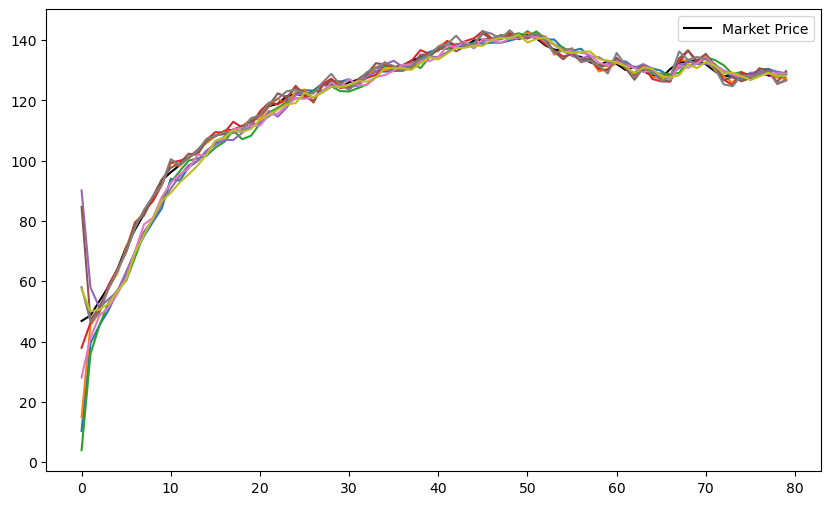

In [18]:
m = market()
m.simulate()
m.graph()